In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score,
                              davies_bouldin_score,
                              calinski_harabasz_score)
from scipy import stats

%matplotlib inline

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#F8F9FA",
    "axes.grid"        : True,
    "grid.alpha"       : 0.35,
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── Fixed palette — Low-Profit to Elite
PALETTE = {
    "Low-Profit" : "#E74C3C",
    "Mid-Profit" : "#F39C12",
    "High-Profit": "#27AE60",
    "Elite"      : "#2980B9",
}
TIERS = ["Low-Profit", "Mid-Profit", "High-Profit", "Elite"]

print("✅  All libraries loaded successfully.")


✅  All libraries loaded successfully.


In [2]:
# ── Update path if your file is in a different location ──────────────────────
DATA_PATH = r"C:\Users\sudhi\Pictures\full_dataset_profit_clv.csv"

df = pd.read_csv(DATA_PATH)
print(f"Raw rows          : {len(df):,}")
print(f"Unique customers  : {df['Customer ID'].nunique():,}")
print(f"Years in dataset  : {sorted(df['Year'].unique())}")

# ── Per-customer aggregation ─────────────────────────────────────────────────
agg = df.groupby("Customer ID").agg(
    ProfitCLV     = ("ProfitCLV",     "sum"),
    CAC           = ("CAC",           "mean"),
    Frequency     = ("Frequency",     "sum"),
    Monetary      = ("Monetary_Value","sum"),
    Years_Active  = ("Year",          "nunique"),
    Province      = ("Province",      "first"),
    Market_Group  = ("Market_Group",  "first"),
).reset_index()

# ── Derived interpretation metrics ───────────────────────────────────────────
agg["NetProfit"]    = agg["ProfitCLV"] - agg["CAC"]
agg["ROI"]          = agg["NetProfit"] / agg["CAC"].replace(0, np.nan)
agg["ProfitPerCAC"] = agg["ProfitCLV"] / agg["CAC"].replace(0, np.nan)

print(f"\nCustomer-level shape : {agg.shape}")
print("\nProfitCLV and CAC summary statistics:")
agg[["ProfitCLV","CAC","NetProfit","ROI"]].describe().round(2)


Raw rows          : 4,344
Unique customers  : 3,580
Years in dataset  : [np.int64(2010), np.int64(2011)]

Customer-level shape : (3580, 11)

ProfitCLV and CAC summary statistics:


,ProfitCLV,CAC,NetProfit,ROI
count,3580.00,3580.00,3580.00,3580.00
mean,1034.31,88.48,945.83,102.14
std,4131.39,280.80,3956.84,5229.91
min,11.53,0.17,10.35,0.16
25%,398.20,36.09,347.15,7.30
50%,652.75,61.34,583.53,8.77
75%,1049.33,92.59,952.63,14.52
max,181487.69,15436.72,181487.11,312908.81


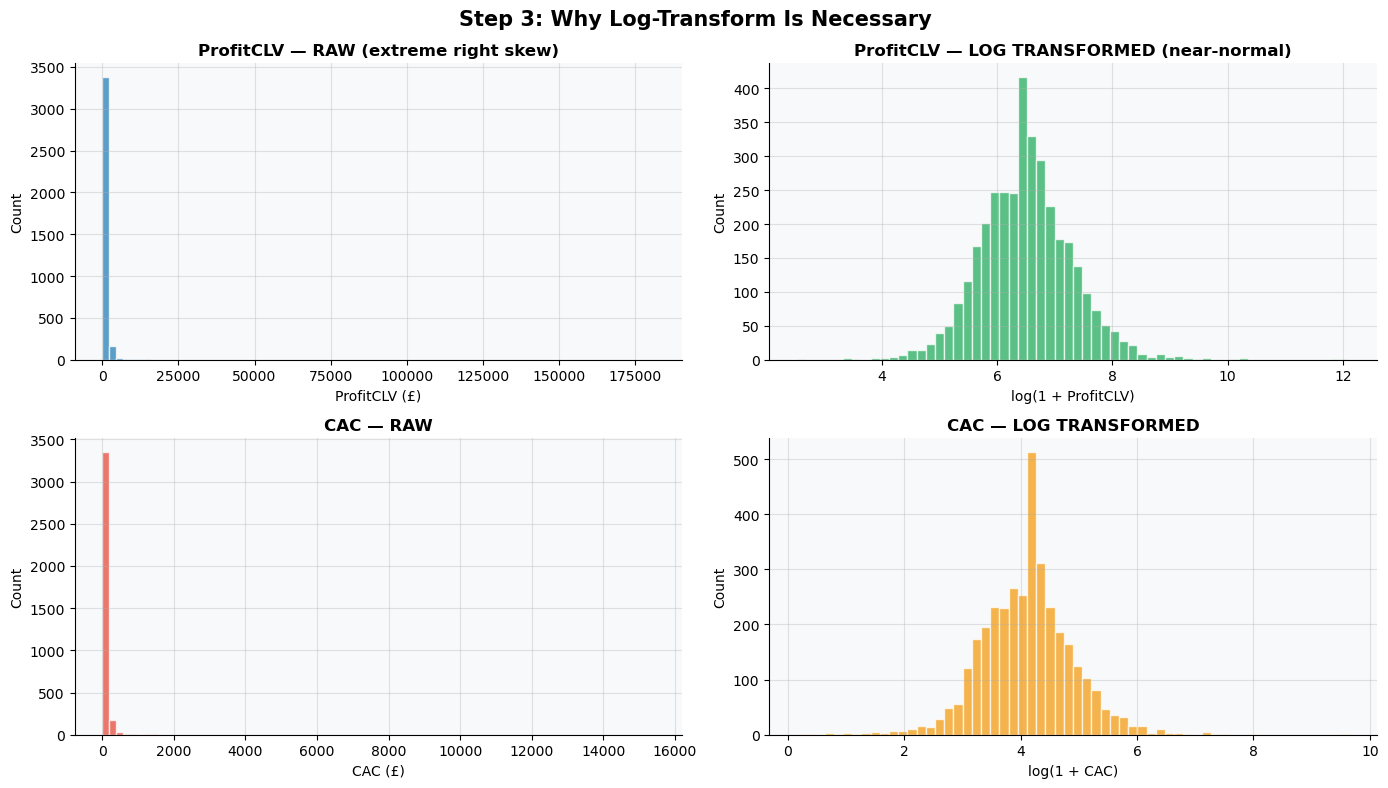

Skewness before log-transform:
  ProfitCLV skewness : 36.94  (>1 = highly skewed)
  CAC skewness       : 46.32

Skewness after log-transform:
  LogCLV skewness    : 0.37  (close to 0 = near-normal)
  LogCAC skewness    : 0.08


In [3]:
# ── Log-transform both features ──────────────────────────────────────────────
agg["LogCLV"] = np.log1p(agg["ProfitCLV"])
agg["LogCAC"] = np.log1p(agg["CAC"])

# ── Visualise the difference ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Step 3: Why Log-Transform Is Necessary", fontsize=15, fontweight="bold")

axes[0,0].hist(agg["ProfitCLV"], bins=80, color="#2980B9", alpha=0.75, edgecolor="white")
axes[0,0].set_title("ProfitCLV — RAW (extreme right skew)", fontweight="bold")
axes[0,0].set_xlabel("ProfitCLV (£)"); axes[0,0].set_ylabel("Count")

axes[0,1].hist(agg["LogCLV"], bins=60, color="#27AE60", alpha=0.75, edgecolor="white")
axes[0,1].set_title("ProfitCLV — LOG TRANSFORMED (near-normal)", fontweight="bold")
axes[0,1].set_xlabel("log(1 + ProfitCLV)"); axes[0,1].set_ylabel("Count")

axes[1,0].hist(agg["CAC"], bins=80, color="#E74C3C", alpha=0.75, edgecolor="white")
axes[1,0].set_title("CAC — RAW", fontweight="bold")
axes[1,0].set_xlabel("CAC (£)"); axes[1,0].set_ylabel("Count")

axes[1,1].hist(agg["LogCAC"], bins=60, color="#F39C12", alpha=0.75, edgecolor="white")
axes[1,1].set_title("CAC — LOG TRANSFORMED", fontweight="bold")
axes[1,1].set_xlabel("log(1 + CAC)"); axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Skewness before log-transform:")
print(f"  ProfitCLV skewness : {agg['ProfitCLV'].skew():.2f}  (>1 = highly skewed)")
print(f"  CAC skewness       : {agg['CAC'].skew():.2f}")
print("\nSkewness after log-transform:")
print(f"  LogCLV skewness    : {agg['LogCLV'].skew():.2f}  (close to 0 = near-normal)")
print(f"  LogCAC skewness    : {agg['LogCAC'].skew():.2f}")


In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(agg[["LogCLV", "LogCAC"]].values)

print("After log-transform + StandardScaler:")
print(f"  Feature 1 (LogCLV)  mean={X_scaled[:,0].mean():.5f}  std={X_scaled[:,0].std():.5f}")
print(f"  Feature 2 (LogCAC)  mean={X_scaled[:,1].mean():.5f}  std={X_scaled[:,1].std():.5f}")
print("\n✅  Both features are now on the same scale — equal weight in K-Means.")


After log-transform + StandardScaler:
  Feature 1 (LogCLV)  mean=0.00000  std=1.00000
  Feature 2 (LogCAC)  mean=0.00000  std=1.00000

✅  Both features are now on the same scale — equal weight in K-Means.


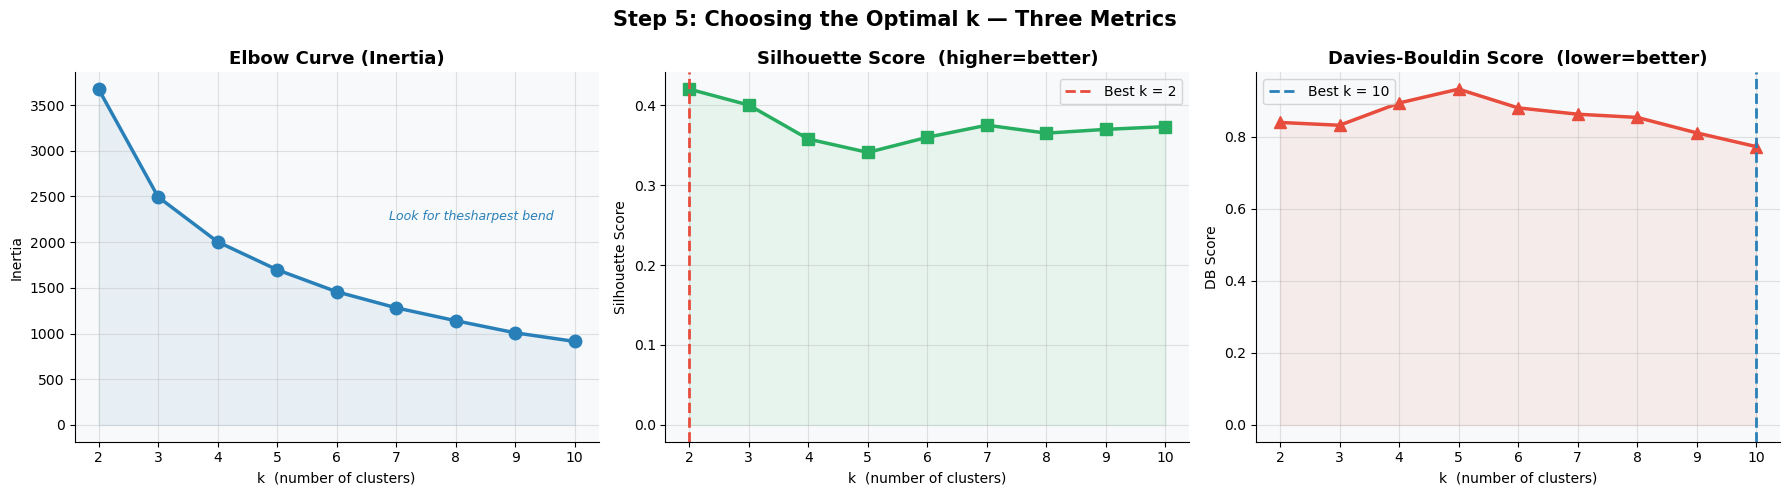

Silhouette best k = 2  (score=0.4200)
Davies-Bouldin best k = 10  (score=0.7726)

All silhouette scores: {2: np.float64(0.42), 3: np.float64(0.4), 4: np.float64(0.358), 5: np.float64(0.341), 6: np.float64(0.36), 7: np.float64(0.375), 8: np.float64(0.365), 9: np.float64(0.37), 10: np.float64(0.373)}


In [6]:
k_range     = range(2, 11)
inertias    = []
silhouettes = []
db_scores   = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# ── Plot all three ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Step 5: Choosing the Optimal k — Three Metrics",
             fontsize=15, fontweight="bold")

axes[0].plot(k_range, inertias, "o-", color="#2980B9", lw=2.5, ms=9)
axes[0].fill_between(k_range, inertias, alpha=0.08, color="#2980B9")
axes[0].set_title("Elbow Curve (Inertia)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("k  (number of clusters)"); axes[0].set_ylabel("Inertia")
axes[0].annotate("Look for thesharpest bend",
                 xy=(0.6,0.6), xycoords="axes fraction", fontsize=9,
                 color="#2980B9", style="italic")

best_sil_k = list(k_range)[silhouettes.index(max(silhouettes))]
axes[1].plot(k_range, silhouettes, "s-", color="#27AE60", lw=2.5, ms=9)
axes[1].fill_between(k_range, silhouettes, alpha=0.08, color="#27AE60")
axes[1].axvline(best_sil_k, color="#E74C3C", ls="--", lw=2,
                label=f"Best k = {best_sil_k}")
axes[1].set_title("Silhouette Score  (higher=better)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("k  (number of clusters)"); axes[1].set_ylabel("Silhouette Score")
axes[1].legend(fontsize=10)

best_db_k = list(k_range)[db_scores.index(min(db_scores))]
axes[2].plot(k_range, db_scores, "^-", color="#E74C3C", lw=2.5, ms=9)
axes[2].fill_between(k_range, db_scores, alpha=0.08, color="#E74C3C")
axes[2].axvline(best_db_k, color="#2980B9", ls="--", lw=2,
                label=f"Best k = {best_db_k}")
axes[2].set_title("Davies-Bouldin Score  (lower=better)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("k  (number of clusters)"); axes[2].set_ylabel("DB Score")
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Silhouette best k = {best_sil_k}  (score={max(silhouettes):.4f})")
print(f"Davies-Bouldin best k = {best_db_k}  (score={min(db_scores):.4f})")
print("\nAll silhouette scores:", {k: round(s,3) for k,s in zip(k_range,silhouettes)})


In [7]:
K_BEST = 4

km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init=30, max_iter=1000)
agg["Cluster_Raw"] = km_final.fit_predict(X_scaled)

# ── Order clusters by mean ProfitCLV (Low → Elite) ───────────────────────────
cluster_order = agg.groupby("Cluster_Raw")["ProfitCLV"].mean().sort_values().index
name_map      = {raw: TIERS[rank] for rank, raw in enumerate(cluster_order)}
agg["Profit_Cluster"] = agg["Cluster_Raw"].map(name_map)

# ── Validation ───────────────────────────────────────────────────────────────
sil = silhouette_score(X_scaled, agg["Cluster_Raw"])
db  = davies_bouldin_score(X_scaled, agg["Cluster_Raw"])
ch  = calinski_harabasz_score(X_scaled, agg["Cluster_Raw"])

print("=" * 55)
print("  NATURAL CLUSTER SIZES  (decided by K-Means, not us)")
print("=" * 55)
for t in TIERS:
    sub = agg[agg["Profit_Cluster"] == t]
    bar = "█" * int(len(sub)/len(agg)*50)
    print(f"  {t:<14}  {len(sub):>5} ({len(sub)/len(agg)*100:5.1f}%)  {bar}")

print(f"\nCluster Validation:")
print(f"  Silhouette Score        : {sil:.4f}   (>0.5 = strong)")
print(f"  Davies-Bouldin Score    : {db:.4f}   (<1.0 = good)")
print(f"  Calinski-Harabasz Score : {ch:.2f}")

  NATURAL CLUSTER SIZES  (decided by K-Means, not us)
  Low-Profit        667 ( 18.6%)  █████████
  Mid-Profit       1471 ( 41.1%)  ████████████████████
  High-Profit      1149 ( 32.1%)  ████████████████
  Elite             293 (  8.2%)  ████

Cluster Validation:
  Silhouette Score        : 0.3576   (>0.5 = strong)
  Davies-Bouldin Score    : 0.8936   (<1.0 = good)
  Calinski-Harabasz Score : 3067.42


In [8]:
profile = agg.groupby("Profit_Cluster").agg(
    Count          = ("ProfitCLV",     "count"),
    Avg_ProfitCLV  = ("ProfitCLV",     "mean"),
    Med_ProfitCLV  = ("ProfitCLV",     "median"),
    Min_ProfitCLV  = ("ProfitCLV",     "min"),
    Max_ProfitCLV  = ("ProfitCLV",     "max"),
    Avg_CAC        = ("CAC",           "mean"),
    Med_CAC        = ("CAC",           "median"),
    Avg_ROI        = ("ROI",           "mean"),
    Avg_NetProfit  = ("NetProfit",     "mean"),
    Avg_ProfitPerCAC=("ProfitPerCAC",  "mean"),
    Avg_Frequency  = ("Frequency",     "mean"),
).reindex(TIERS).round(2)

profile.insert(1, "Share_%",
    (profile["Count"] / profile["Count"].sum() * 100).round(1))

print("Cluster Profile Summary:")
profile

Cluster Profile Summary:


,Count,Share_%,Avg_ProfitCLV,Med_ProfitCLV,Min_ProfitCLV,Max_ProfitCLV,Avg_CAC,Med_CAC,Avg_ROI,Avg_NetProfit,Avg_ProfitPerCAC,Avg_Frequency
Profit_Cluster,,,,,,,,,,,,
Low-Profit,667,18.6,265.93,255.51,11.53,1571.52,22.69,22.94,22.87,243.24,23.87,3.58
Mid-Profit,1471,41.1,579.48,557.41,189.57,6745.40,52.27,51.28,12.76,527.21,13.76,5.41
High-Profit,1149,32.1,1159.78,1041.33,306.12,5319.01,104.57,93.45,12.54,1055.21,13.54,8.84
Elite,293,8.2,4574.96,2598.70,730.66,181487.69,356.95,219.76,1082.64,4218.00,1083.64,14.50


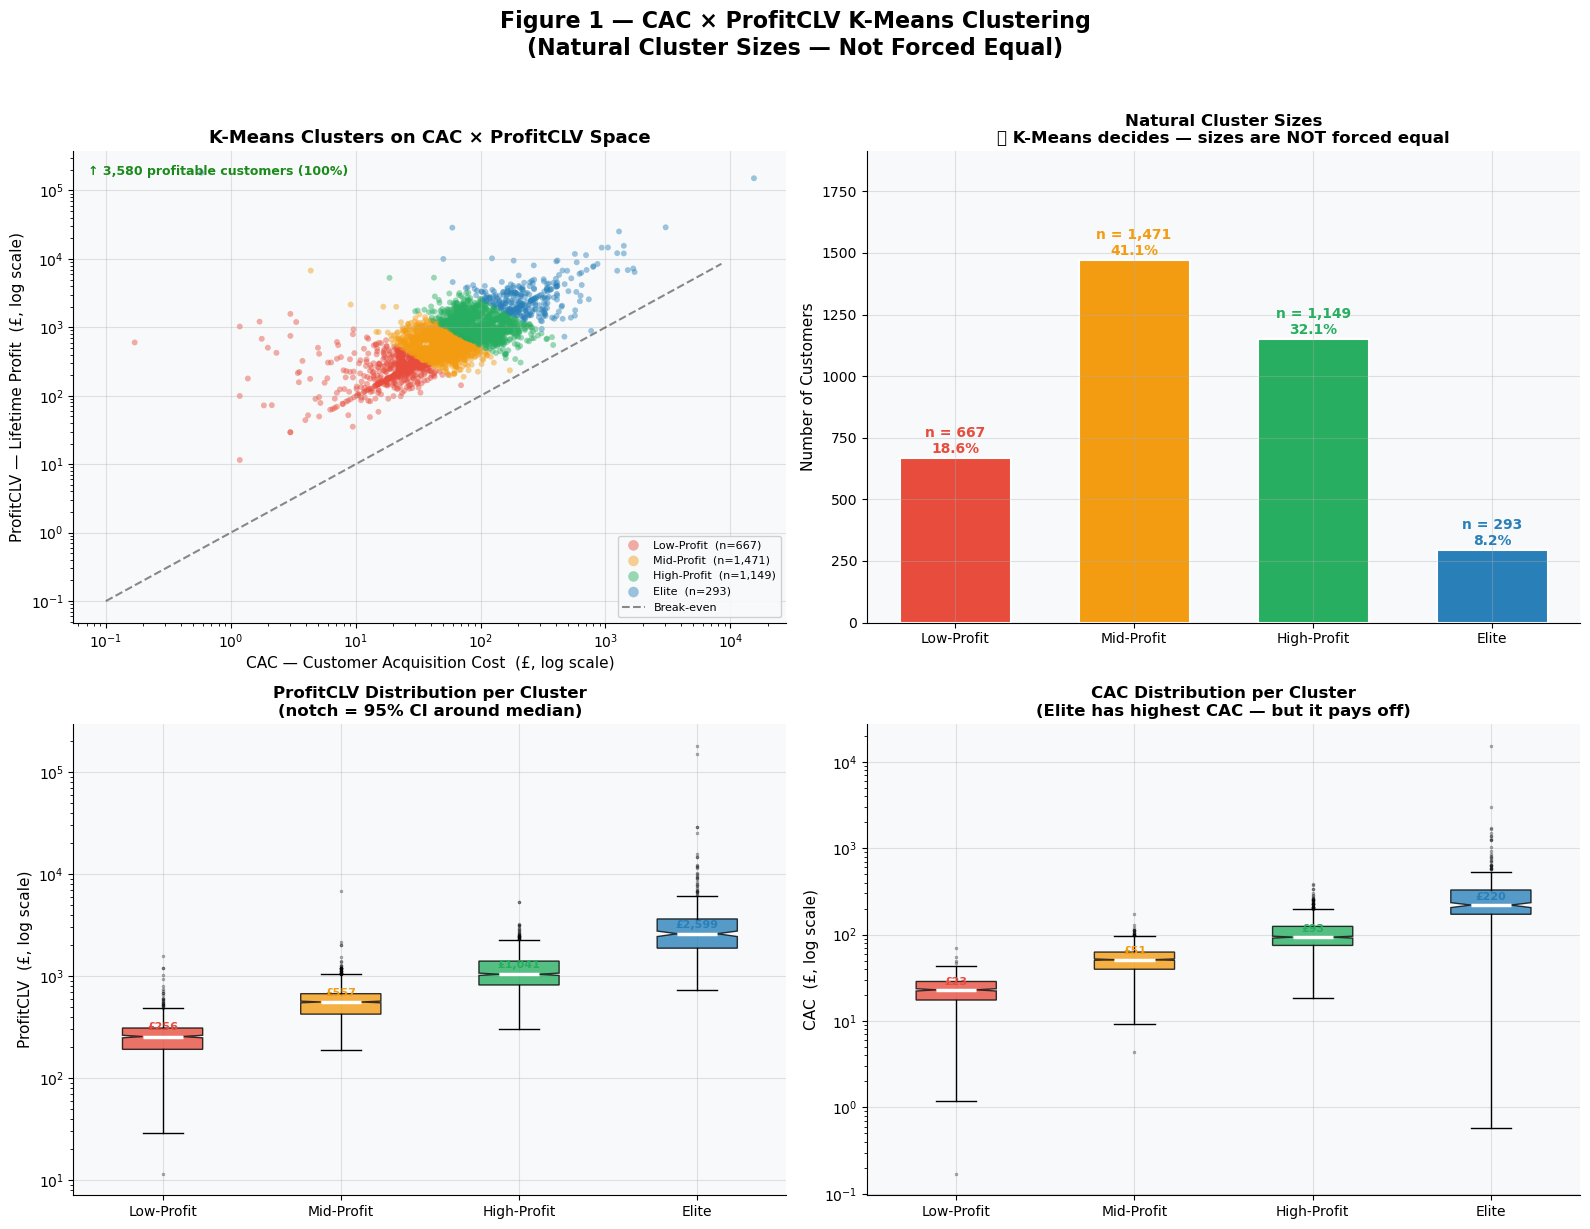

In [9]:
fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle("Figure 1 — CAC × ProfitCLV K-Means Clustering\n(Natural Cluster Sizes — Not Forced Equal)",
              fontsize=16, fontweight="bold", y=1.02)

# ── A: Scatter ───────────────────────────────────────────────────────────────
ax = axes[0, 0]
for tier in TIERS:
    sub = agg[agg["Profit_Cluster"] == tier]
    ax.scatter(sub["CAC"], sub["ProfitCLV"],
               c=PALETTE[tier], alpha=0.45, s=18,
               label=f"{tier}  (n={len(sub):,})", edgecolors="none")

# break-even line
xlim = np.percentile(agg["CAC"].dropna(), 99.5)
ylim = np.percentile(agg["ProfitCLV"].dropna(), 99.5)
bound = max(xlim, ylim)
ax.plot([0.1, bound], [0.1, bound], "k--", lw=1.5, alpha=0.45, label="Break-even")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("CAC — Customer Acquisition Cost  (£, log scale)", fontsize=11)
ax.set_ylabel("ProfitCLV — Lifetime Profit  (£, log scale)", fontsize=11)
ax.set_title("K-Means Clusters on CAC × ProfitCLV Space", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, markerscale=1.8, framealpha=0.9)

# above break-even annotation
n_profitable = (agg["ProfitCLV"] > agg["CAC"]).sum()
ax.annotate(f"↑ {n_profitable:,} profitable customers ({n_profitable/len(agg)*100:.0f}%)",
            xy=(0.02, 0.97), xycoords="axes fraction", fontsize=9,
            color="#1A8A1A", fontweight="bold", va="top")

# ── B: Natural cluster sizes ──────────────────────────────────────────────────
ax = axes[0, 1]
sizes = agg["Profit_Cluster"].value_counts().reindex(TIERS)
colors_list = [PALETTE[t] for t in TIERS]
bars = ax.bar(TIERS, sizes.values, color=colors_list, edgecolor="white", lw=1.5, width=0.62)
for bar, val, tier in zip(bars, sizes.values, TIERS):
    pct = val / len(agg) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f"n = {val:,}\n{pct:.1f}%",
            ha="center", va="bottom", fontsize=10,
            fontweight="bold", color=PALETTE[tier])
ax.set_ylabel("Number of Customers", fontsize=11)
ax.set_title("Natural Cluster Sizes\n✅ K-Means decides — sizes are NOT forced equal",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, sizes.max() * 1.3)

# ── C: ProfitCLV box plots ───────────────────────────────────────────────────
ax = axes[1, 0]
data_clv = [agg.loc[agg["Profit_Cluster"] == t, "ProfitCLV"].values for t in TIERS]
bp1 = ax.boxplot(data_clv, patch_artist=True, notch=True,
                 medianprops=dict(color="white", lw=2.5),
                 flierprops=dict(marker=".", ms=3, alpha=0.35))
for patch, tier in zip(bp1["boxes"], TIERS):
    patch.set_facecolor(PALETTE[tier]); patch.set_alpha(0.78)
for i, tier in enumerate(TIERS):
    med = agg.loc[agg["Profit_Cluster"] == tier, "ProfitCLV"].median()
    ax.text(i+1, med*1.15, f"£{med:,.0f}", ha="center", fontsize=8,
            fontweight="bold", color=PALETTE[tier])
ax.set_xticklabels(TIERS, fontsize=10); ax.set_yscale("log")
ax.set_ylabel("ProfitCLV  (£, log scale)", fontsize=11)
ax.set_title("ProfitCLV Distribution per Cluster\n(notch = 95% CI around median)",
             fontsize=12, fontweight="bold")

# ── D: CAC box plots ─────────────────────────────────────────────────────────
ax = axes[1, 1]
data_cac = [agg.loc[agg["Profit_Cluster"] == t, "CAC"].values for t in TIERS]
bp2 = ax.boxplot(data_cac, patch_artist=True, notch=True,
                 medianprops=dict(color="white", lw=2.5),
                 flierprops=dict(marker=".", ms=3, alpha=0.35))
for patch, tier in zip(bp2["boxes"], TIERS):
    patch.set_facecolor(PALETTE[tier]); patch.set_alpha(0.78)
for i, tier in enumerate(TIERS):
    med = agg.loc[agg["Profit_Cluster"] == tier, "CAC"].median()
    ax.text(i+1, med*1.15, f"£{med:,.0f}", ha="center", fontsize=8,
            fontweight="bold", color=PALETTE[tier])
ax.set_xticklabels(TIERS, fontsize=10); ax.set_yscale("log")
ax.set_ylabel("CAC  (£, log scale)", fontsize=11)
ax.set_title("CAC Distribution per Cluster\n(Elite has highest CAC — but it pays off)",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

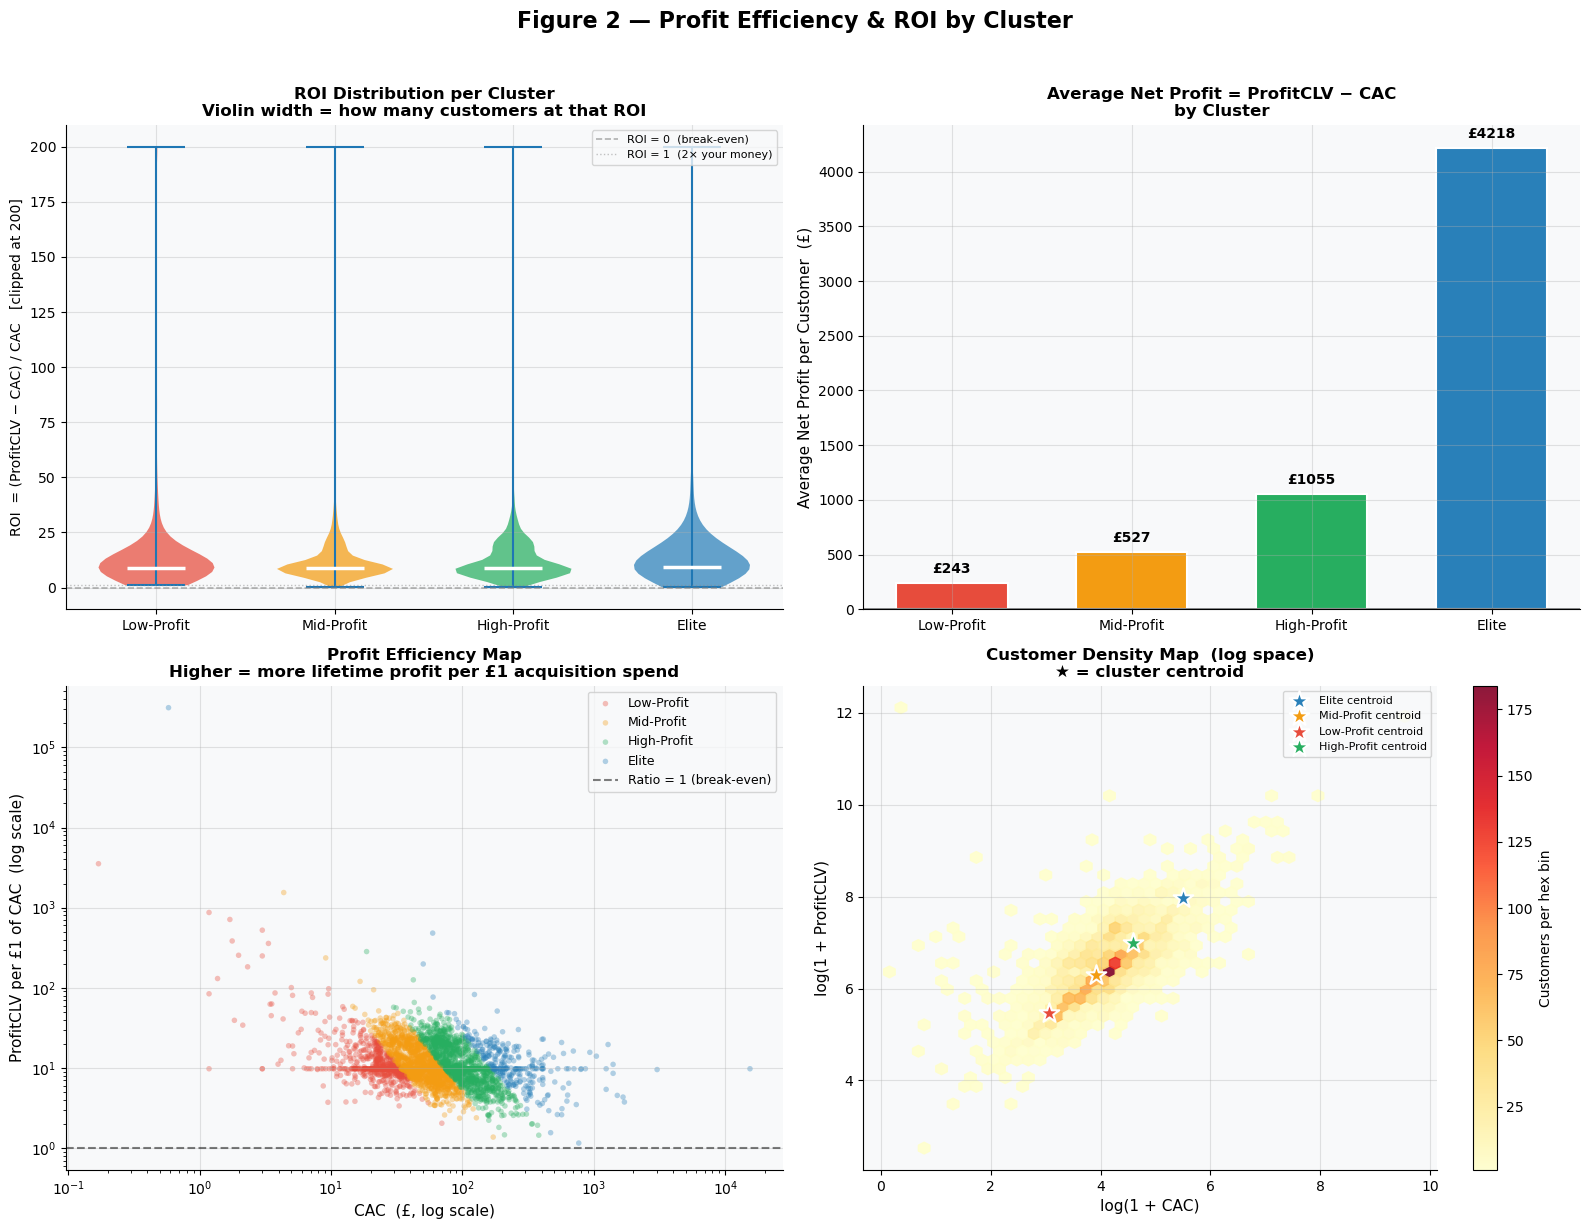

In [10]:
fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Figure 2 — Profit Efficiency & ROI by Cluster",
              fontsize=16, fontweight="bold", y=1.02)

# ── A: ROI violin ─────────────────────────────────────────────────────────────
ax = axes[0, 0]
roi_data = [np.clip(agg.loc[agg["Profit_Cluster"]==t, "ROI"].dropna().values, -2, 200)
            for t in TIERS]
vp = ax.violinplot(roi_data, positions=range(4), showmedians=True, widths=0.65)
for pc, tier in zip(vp["bodies"], TIERS):
    pc.set_facecolor(PALETTE[tier]); pc.set_alpha(0.72)
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2.5)
ax.set_xticks(range(4)); ax.set_xticklabels(TIERS, fontsize=10)
ax.axhline(0, color="gray", ls="--", lw=1.2, alpha=0.6, label="ROI = 0  (break-even)")
ax.axhline(1, color="#888", ls=":", lw=1, alpha=0.5, label="ROI = 1  (2× your money)")
ax.set_ylabel("ROI  = (ProfitCLV − CAC) / CAC   [clipped at 200]", fontsize=10)
ax.set_title("ROI Distribution per Cluster\nViolin width = how many customers at that ROI",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8)

# ── B: Net profit bar ─────────────────────────────────────────────────────────
ax = axes[0, 1]
net_means = agg.groupby("Profit_Cluster")["NetProfit"].mean().reindex(TIERS)
bars = ax.bar(TIERS, net_means.values,
              color=[PALETTE[t] for t in TIERS], edgecolor="white", lw=1.5, width=0.62)
ax.bar_label(bars, fmt="£%.0f", fontsize=10, fontweight="bold", padding=5)
ax.axhline(0, color="black", lw=1.2, alpha=0.5)
ax.set_ylabel("Average Net Profit per Customer  (£)", fontsize=11)
ax.set_title("Average Net Profit = ProfitCLV − CAC\nby Cluster",
             fontsize=12, fontweight="bold")

# ── C: CLV/CAC efficiency scatter ────────────────────────────────────────────
ax = axes[1, 0]
for tier in TIERS:
    sub = agg[agg["Profit_Cluster"]==tier]
    ax.scatter(sub["CAC"], sub["ProfitPerCAC"],
               c=PALETTE[tier], alpha=0.35, s=16, label=tier, edgecolors="none")
ax.axhline(1, color="black", ls="--", lw=1.5, alpha=0.5, label="Ratio = 1 (break-even)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("CAC  (£, log scale)", fontsize=11)
ax.set_ylabel("ProfitCLV per £1 of CAC  (log scale)", fontsize=11)
ax.set_title("Profit Efficiency Map\nHigher = more lifetime profit per £1 acquisition spend",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

# ── D: 2D hexbin density + centroids ─────────────────────────────────────────
ax = axes[1, 1]
hb = ax.hexbin(agg["LogCAC"], agg["LogCLV"], gridsize=45,
               cmap="YlOrRd", mincnt=1, alpha=0.9)
plt.colorbar(hb, ax=ax, label="Customers per hex bin")

# centroids in log-space (unscale → log-space)
scaler_temp = StandardScaler().fit(agg[["LogCLV","LogCAC"]].values)
cent_log    = scaler_temp.inverse_transform(km_final.cluster_centers_)
for (c_logclv, c_logcac), raw_id in zip(cent_log, range(K_BEST)):
    tier = name_map[raw_id]
    ax.scatter(c_logcac, c_logclv, s=220, c=PALETTE[tier],
               marker="*", edgecolors="white", lw=1.5, zorder=6, label=f"{tier} centroid")

ax.set_xlabel("log(1 + CAC)", fontsize=11)
ax.set_ylabel("log(1 + ProfitCLV)", fontsize=11)
ax.set_title("Customer Density Map  (log space)\n★ = cluster centroid",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


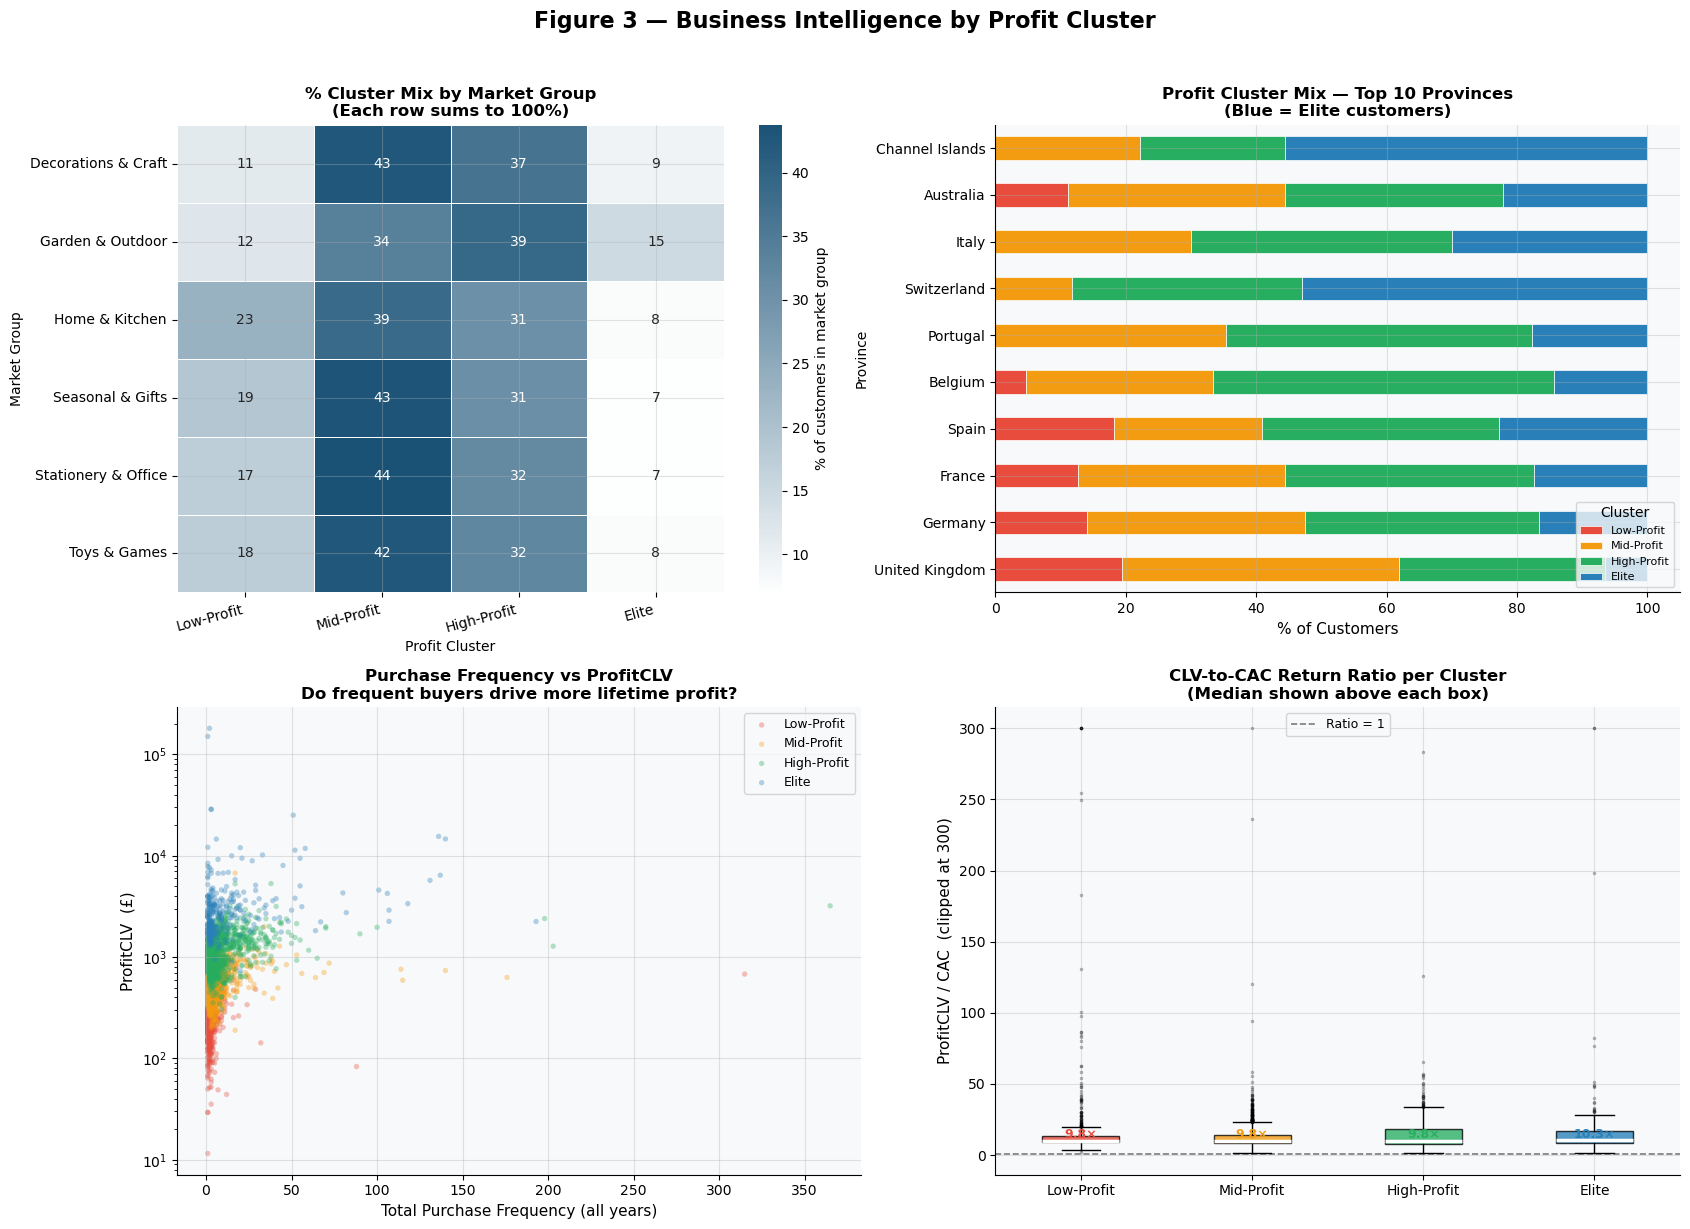

In [11]:
fig3, axes = plt.subplots(2, 2, figsize=(17, 12))
fig3.suptitle("Figure 3 — Business Intelligence by Profit Cluster",
              fontsize=16, fontweight="bold", y=1.02)

# ── A: Market group heatmap ───────────────────────────────────────────────────
ax = axes[0, 0]
mg = (agg.groupby(["Market_Group","Profit_Cluster"])
      .size().unstack(fill_value=0).reindex(columns=TIERS, fill_value=0))
mg_pct = mg.div(mg.sum(axis=1), axis=0) * 100
cmap_h = LinearSegmentedColormap.from_list("g", ["#FDFEFE","#1A5276"])
sns.heatmap(mg_pct, ax=ax, cmap=cmap_h,
            annot=True, fmt=".0f", linewidths=0.5, linecolor="white",
            cbar_kws={"label":"% of customers in market group"})
ax.set_title("% Cluster Mix by Market Group\n(Each row sums to 100%)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Profit Cluster"); ax.set_ylabel("Market Group")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")

# ── B: Province stacked bar ───────────────────────────────────────────────────
ax = axes[0, 1]
prov = (agg.groupby(["Province","Profit_Cluster"])
        .size().unstack(fill_value=0).reindex(columns=TIERS, fill_value=0))
top10 = prov.sum(axis=1).nlargest(10).index
pct   = prov.loc[top10].div(prov.loc[top10].sum(axis=1), axis=0) * 100
pct.plot(kind="barh", stacked=True, ax=ax,
         color=[PALETTE[t] for t in TIERS], edgecolor="white", lw=0.5)
ax.set_xlabel("% of Customers", fontsize=11)
ax.set_title("Profit Cluster Mix — Top 10 Provinces\n(Blue = Elite customers)",
             fontsize=12, fontweight="bold")
ax.legend(title="Cluster", fontsize=8, loc="lower right")

# ── C: Frequency vs ProfitCLV ─────────────────────────────────────────────────
ax = axes[1, 0]
for tier in TIERS:
    sub = agg[agg["Profit_Cluster"]==tier]
    ax.scatter(sub["Frequency"], sub["ProfitCLV"],
               c=PALETTE[tier], alpha=0.35, s=15, label=tier, edgecolors="none")
ax.set_xlabel("Total Purchase Frequency (all years)", fontsize=11)
ax.set_ylabel("ProfitCLV  (£)", fontsize=11)
ax.set_yscale("log")
ax.set_title("Purchase Frequency vs ProfitCLV\nDo frequent buyers drive more lifetime profit?",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

# ── D: ProfitPerCAC box by cluster ────────────────────────────────────────────
ax = axes[1, 1]
ratio_d = [agg.loc[agg["Profit_Cluster"]==t, "ProfitPerCAC"].dropna().clip(0,300).values
           for t in TIERS]
bp = ax.boxplot(ratio_d, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2.5),
                flierprops=dict(marker=".", ms=3, alpha=0.3))
for patch, tier in zip(bp["boxes"], TIERS):
    patch.set_facecolor(PALETTE[tier]); patch.set_alpha(0.78)
for i, tier in enumerate(TIERS):
    med = agg.loc[agg["Profit_Cluster"]==tier, "ProfitPerCAC"].median()
    ax.text(i+1, med+2, f"{med:.1f}×", ha="center", fontsize=9,
            fontweight="bold", color=PALETTE[tier])
ax.set_xticklabels(TIERS, fontsize=10)
ax.set_ylabel("ProfitCLV / CAC  (clipped at 300)", fontsize=11)
ax.axhline(1, color="black", ls="--", lw=1.2, alpha=0.5, label="Ratio = 1")
ax.set_title("CLV-to-CAC Return Ratio per Cluster\n(Median shown above each box)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [12]:
print(f"{'Metric':<22}  {'F-statistic':>13}  {'p-value':>13}  Significance")
print("─" * 65)
for col, label in [
    ("ProfitCLV",    "ProfitCLV"),
    ("CAC",          "CAC"),
    ("ROI",          "ROI"),
    ("NetProfit",    "Net Profit"),
    ("ProfitPerCAC", "CLV/CAC Ratio"),
    ("Frequency",    "Frequency"),
]:
    groups = [agg.loc[agg["Profit_Cluster"]==t, col].dropna().values for t in TIERS]
    F, p   = stats.f_oneway(*groups)
    if   p < 0.001: sig = "***  highly significant"
    elif p < 0.01:  sig = "**   significant"
    elif p < 0.05:  sig = "*    marginally significant"
    else:           sig = "ns   not significant"
    print(f"  {label:<20}  {F:>13.2f}  {p:>13.2e}  {sig}")

print("\n*** Interpretation: All primary profit metrics are highly statistically")
print("    significant across clusters — the segments are real, not random.")


Metric                    F-statistic        p-value  Significance
─────────────────────────────────────────────────────────────────
  ProfitCLV                     92.28       1.61e-57  ***  highly significant
  CAC                          122.16       2.54e-75  ***  highly significant
  ROI                            3.75       1.06e-02  *    marginally significant
  Net Profit                    85.20       3.05e-53  ***  highly significant
  CLV/CAC Ratio                  3.75       1.06e-02  *    marginally significant
  Frequency                     49.72       1.77e-31  ***  highly significant

*** Interpretation: All primary profit metrics are highly statistically
    significant across clusters — the segments are real, not random.


In [13]:
export = agg[["Customer ID","ProfitCLV","CAC","Profit_Cluster",
              "ROI","NetProfit","ProfitPerCAC",
              "Frequency","Monetary","Years_Active",
              "Province","Market_Group"]].copy()
export.to_csv("customer_cac_clv_clusters.csv", index=False)
print("✅  Saved → customer_cac_clv_clusters.csv")
print(f"   Rows: {len(export):,}")
export.head(10)


✅  Saved → customer_cac_clv_clusters.csv
   Rows: 3,580


,Customer ID,ProfitCLV,CAC,Profit_Cluster,ROI,NetProfit,ProfitPerCAC,Frequency,Monetary,Years_Active,Province,Market_Group
0,12346,150856.5078,15436.720,Elite,8.772575,135419.7878,9.772575,1,77183.60,1,United Kingdom,Home & Kitchen
1,12347,2673.5102,118.718,Elite,21.519839,2554.7922,22.519839,8,4921.53,2,Iceland,Decorations & Craft
2,12348,1408.4711,112.024,High-Profit,11.572941,1296.4471,12.572941,5,1658.40,2,Finland,Seasonal & Gifts
3,12349,2788.8034,351.510,Elite,6.933781,2437.2934,7.933781,1,1457.55,1,Italy,Stationery & Office
4,12352,367.2140,59.300,Mid-Profit,5.192479,307.9140,6.192479,7,1385.74,1,Norway,Seasonal & Gifts
5,12353,173.9518,17.800,Low-Profit,8.772573,156.1518,9.772573,1,89.00,1,Bahrain,Seasonal & Gifts
6,12355,897.9042,91.880,High-Profit,8.772575,806.0242,9.772575,1,459.40,1,Bahrain,Seasonal & Gifts
7,12356,1332.0777,454.324,Elite,1.931999,877.7537,2.931999,3,2487.43,1,Portugal,Seasonal & Gifts
8,12357,12132.9844,1241.534,Elite,8.772575,10891.4504,9.772575,1,6207.67,1,Switzerland,Garden & Outdoor
9,12358,902.7876,96.972,High-Profit,8.309776,805.8156,9.309776,2,928.06,1,Austria,Seasonal & Gifts
